# Judge accuracy (Alt-Test)

Same scoring path as `uv run run_judges.py --accuracy-only`: each judge is scored against the three human ratings with the [Alternative Annotator Test](https://arxiv.org/abs/2501.10970).

Headline number is **average advantage probability ρ** (chance the judge is as good as or better than a randomly chosen annotator). Winning rate **ω** uses ε = 0.15 and is secondary. **llm** / **hum** are leave-one-out agreement with the other two labelers.

Unparsed judge replies are **not** treated as an Incorrect verdict. They enter the Alt-Test as a label that matches neither human pass nor fail, so they count as disagreements. **parse** is the share of stored answers with a `pass`/`fail` verdict.

ρ intervals are 95% question-clustered bootstrap CIs. Charts omit prompt modes with no verdicts.


In [13]:
%matplotlib inline
from __future__ import annotations

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from grader import JUDGE_FORMATS, grade_mode_title, grade_prompt_names, parse_judge_key
from run_judges import LOCAL_PACK_DIR, report_judge_accuracy

plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.axisbelow": True,
        "font.size": 11,
        "axes.titlesize": 13,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)

payload = report_judge_accuracy(LOCAL_PACK_DIR)
print(
    f"\npack={payload['pack']}  rows={payload['n_label_rows']}  "
    f"questions={payload['n_questions']}  ε={payload['epsilon']}"
)


=== judge Alt-Test (judge_no_gt (hears audio, no gold), ε=0.150) ===
llm = judge agreement with the other two labelers (leave-one-out ACC)
hum = excluded labeler's agreement with those same two
parse = share of stored judge answers with a pass/fail verdict
judge                                                     n   miss    unp    parse     <3        ρ      llm      hum        ω  pass
af-next-think__judge_no_gt__nongold                    3834      0    181    0.960    729    0.622    0.540    0.889    0.000    no
gemma-4-12b__judge_no_gt__nongold                      3834      0      0    1.000    729    0.570    0.485    0.889    0.000    no
gemma-4-e4b__judge_no_gt__nongold                      3834      0     13    0.997    729    0.565    0.483    0.889    0.000    no
nemotron-3-nano-omni__judge_no_gt__nongold             3834      0     77    0.983    729    0.680    0.598    0.889    0.000    no
phi-4-multimodal__judge_no_gt__nongold                 3834      0      1    1.000

In [14]:
_MODE_PALETTE = (
    "#4C78A8",
    "#F58518",
    "#54A24B",
    "#72B7B2",
    "#E45756",
    "#B279A2",
    "#FF9DA6",
    "#9D755D",
    "#BAB0AC",
    "#F2CF5B",
)
MODE_ORDER = [m for m in grade_prompt_names() if payload.get(m)]
MODE_COLORS = {
    name: _MODE_PALETTE[i % len(_MODE_PALETTE)]
    for i, name in enumerate(grade_prompt_names())
}


def flatten_accuracy(payload: dict) -> pd.DataFrame:
    rows = []
    for mode in MODE_ORDER:
        by_judge = payload.get(mode) or {}
        if not isinstance(by_judge, dict) or not by_judge:
            continue
        fmt = JUDGE_FORMATS.get(mode)
        for key, stats in sorted(by_judge.items()):
            parsed = parse_judge_key(key)
            model = parsed.get("model") or key
            prompt = parsed.get("prompt") or mode
            rows.append(
                {
                    "key": key,
                    "model": model,
                    "prompt": prompt,
                    "mode": mode,
                    "mode_title": grade_mode_title(mode),
                    "sees_gold": None if fmt is None else bool(fmt.include_gold),
                    "hears_audio": None if fmt is None else bool(fmt.audio_included),
                    "n": stats.get("n"),
                    "n_missing": stats.get("n_missing"),
                    "n_unparsed": stats.get("n_unparsed"),
                    "parse_rate": stats.get("parse_rate"),
                    "n_skipped_lt3": stats.get("n_skipped_lt3"),
                    "rho": stats.get("advantage_prob"),
                    "rho_lo": stats.get("advantage_prob_ci_low"),
                    "rho_hi": stats.get("advantage_prob_ci_high"),
                    "llm": stats.get("loo_agree_judge"),
                    "hum": stats.get("loo_agree_human"),
                    "omega": stats.get("winning_rate"),
                    "passed": stats.get("passed"),
                }
            )
    return pd.DataFrame(rows)


df = flatten_accuracy(payload)
if df.empty:
    raise SystemExit(f"No scored judges in {LOCAL_PACK_DIR}")

model_order = list(
    dict.fromkeys(
        df.loc[df["mode"] == MODE_ORDER[0]]
        .sort_values("rho", ascending=False)["model"]
        .tolist()
    )
)
for model in df["model"]:
    if model not in model_order:
        model_order.append(model)
df["model"] = pd.Categorical(df["model"], categories=model_order, ordered=True)
df["mode"] = pd.Categorical(df["mode"], categories=MODE_ORDER, ordered=True)
df = df.sort_values(["mode", "model"]).reset_index(drop=True)


def mode_label(mode: str) -> str:
    return grade_mode_title(mode).replace(" (", "\n(", 1)


def pivot(metric: str) -> pd.DataFrame:
    return (
        df.pivot_table(index="model", columns="mode", values=metric, observed=True)
        .reindex(index=model_order, columns=MODE_ORDER)
    )


summary = (
    df.groupby("mode", observed=True)
    .agg(
        n_judges=("key", "size"),
        n_pass=("passed", lambda s: int(s.fillna(False).astype(bool).sum())),
        mean_rho=("rho", "mean"),
        mean_llm=("llm", "mean"),
        mean_hum=("hum", "mean"),
        mean_parse=("parse_rate", "mean"),
    )
    .reindex(MODE_ORDER)
)
print("By prompt mode")
display(summary.round(3))
print("Per judge (same columns as --accuracy-only)")
display(
    df[
        [
            "mode",
            "model",
            "prompt",
            "n",
            "n_missing",
            "n_unparsed",
            "parse_rate",
            "n_skipped_lt3",
            "rho",
            "rho_lo",
            "rho_hi",
            "llm",
            "hum",
            "omega",
            "passed",
        ]
    ].style.format(
        {
            "parse_rate": "{:.3f}",
            "rho": "{:.3f}",
            "rho_lo": "{:.3f}",
            "rho_hi": "{:.3f}",
            "llm": "{:.3f}",
            "hum": "{:.3f}",
            "omega": "{:.3f}",
        },
        na_rep="—",
    )
)

By prompt mode


,n_judges,n_pass,mean_rho,mean_llm,mean_hum,mean_parse
mode,,,,,,
judge_no_gt,7,0,0.645,0.563,0.889,0.991
judge_with_gt,7,6,0.885,0.808,0.889,0.991
judge_with_gt_no_audio,7,6,0.921,0.845,0.889,0.999
with_gt,7,5,0.910,0.833,0.889,0.996
with_gt_with_audio,7,6,0.918,0.842,0.889,0.995
free,7,0,0.676,0.595,0.889,0.996
neutral_with_gt,7,6,0.914,0.838,0.889,0.996
neutral_with_gt_no_audio,7,7,0.929,0.854,0.889,0.999
neutral_no_gt,7,0,0.657,0.575,0.889,0.994


Per judge (same columns as --accuracy-only)


,mode,model,prompt,n,n_missing,n_unparsed,parse_rate,n_skipped_lt3,rho,rho_lo,rho_hi,llm,hum,omega,passed
0,judge_no_gt,phi-4-multimodal,judge_no_gt,3834,0,1,1.000,729,0.788,0.756,0.819,0.708,0.889,0.000,False
1,judge_no_gt,nemotron-3-nano-omni,judge_no_gt,3834,0,77,0.983,729,0.680,0.640,0.715,0.598,0.889,0.000,False
2,judge_no_gt,qwen3-omni,judge_no_gt,3834,0,0,1.000,729,0.680,0.641,0.719,0.596,0.889,0.000,False
3,judge_no_gt,af-next-think,judge_no_gt,3834,0,181,0.960,729,0.622,0.587,0.655,0.540,0.889,0.000,False
4,judge_no_gt,voxtral-small-24b,judge_no_gt,3834,0,10,0.998,729,0.613,0.568,0.654,0.530,0.889,0.000,False
5,judge_no_gt,gemma-4-12b,judge_no_gt,3834,0,0,1.000,729,0.570,0.526,0.610,0.485,0.889,0.000,False
6,judge_no_gt,gemma-4-e4b,judge_no_gt,3834,0,13,0.997,729,0.565,0.519,0.607,0.483,0.889,0.000,False
7,judge_with_gt,phi-4-multimodal,judge_with_gt,3834,0,0,1.000,729,0.856,0.828,0.882,0.778,0.889,1.000,True
8,judge_with_gt,nemotron-3-nano-omni,judge_with_gt,3834,0,24,0.995,729,0.925,0.904,0.944,0.849,0.889,1.000,True
9,judge_with_gt,qwen3-omni,judge_with_gt,3834,0,1,1.000,729,0.945,0.931,0.957,0.870,0.889,1.000,True


## ρ by judge and prompt

Average advantage probability. Each cell is ρ and its 95% CI `[lo, hi]`. A `*` marks an Alt-Test pass (ω > 0.5 at ε = 0.15). Gold prompts sit near the human ceiling; no-gold prompts do not.


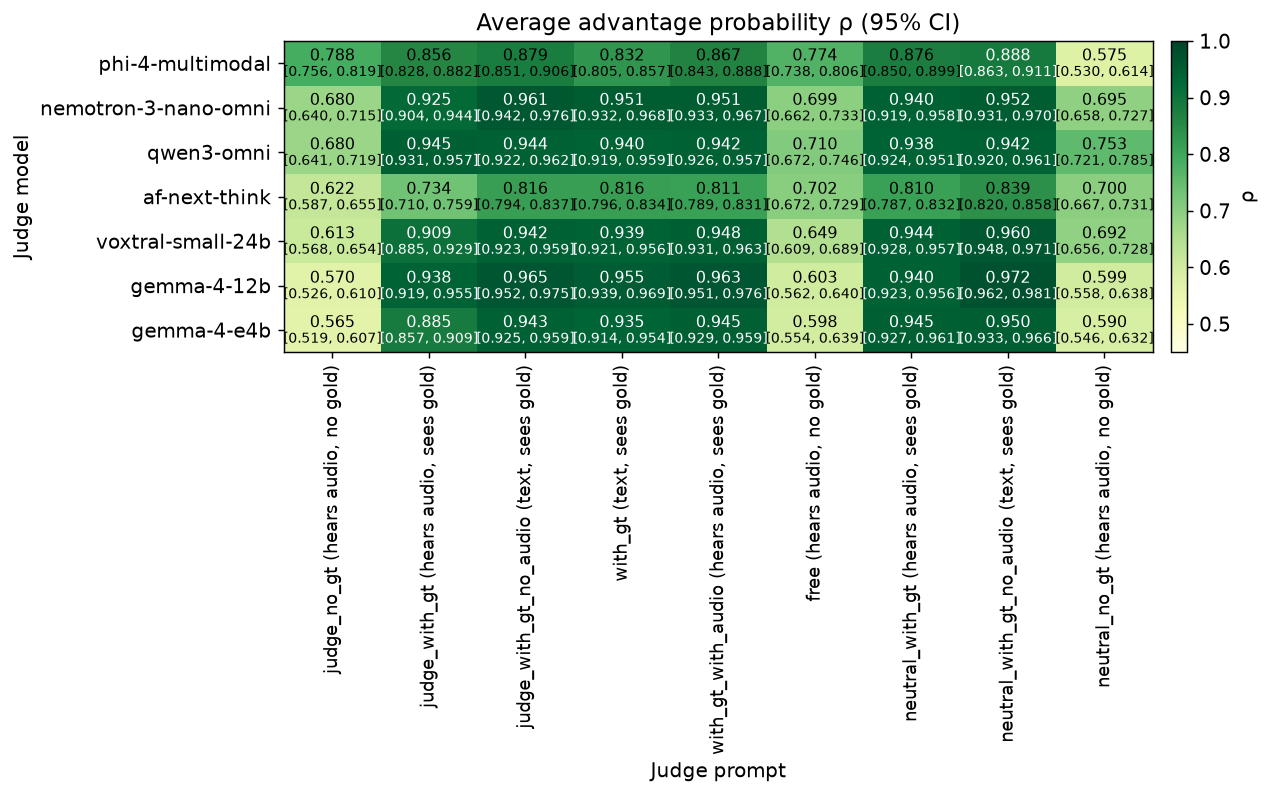

In [15]:
rho = pivot("rho")
rho_lo = pivot("rho_lo")
rho_hi = pivot("rho_hi")
passed = pivot("passed")

fig, ax = plt.subplots(figsize=(10, 0.55 * len(model_order) + 2.4))
data = rho.to_numpy(dtype=float)
lo_g = rho_lo.to_numpy(dtype=float)
hi_g = rho_hi.to_numpy(dtype=float)
masked = np.ma.masked_invalid(data)
im = ax.imshow(masked, aspect="auto", cmap="YlGn", vmin=0.45, vmax=1.0)
ax.set_xticks(np.arange(len(MODE_ORDER)))
ax.set_xticklabels(
    [grade_mode_title(m) for m in MODE_ORDER],
    rotation=90,
    ha="center",
    va="top",
    fontsize=10,
)
ax.set_yticks(np.arange(len(model_order)))
ax.set_yticklabels(model_order)
ax.set_title("Average advantage probability ρ (95% CI)")
ax.set_xlabel("Judge prompt")
ax.set_ylabel("Judge model")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        value = data[i, j]
        if np.isnan(value):
            continue
        star = "*" if passed.iloc[i, j] is True else ""
        ink = "white" if value >= 0.88 else "black"
        ax.text(
            j,
            i - 0.16,
            f"{value:.3f}{star}",
            ha="center",
            va="center",
            color=ink,
            fontsize=9,
        )
        lo, hi = lo_g[i, j], hi_g[i, j]
        if np.isfinite(lo) and np.isfinite(hi):
            ax.text(
                j,
                i + 0.20,
                f"[{lo:.3f}, {hi:.3f}]",
                ha="center",
                va="center",
                color=ink,
                fontsize=8,
            )

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("ρ")
fig.tight_layout()
plt.show()


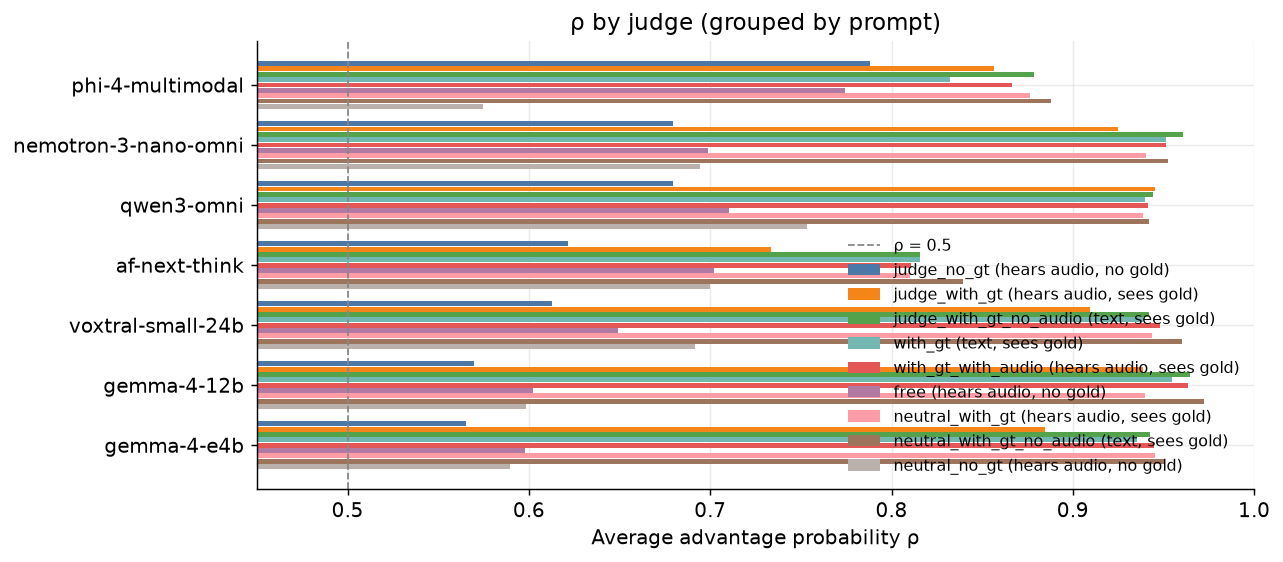

In [16]:
fig, ax = plt.subplots(figsize=(10, 0.38 * len(model_order) + 1.8))
n_modes = len(MODE_ORDER)
width = 0.8 / n_modes
y = np.arange(len(model_order))
for i, mode in enumerate(MODE_ORDER):
    sub = df[df["mode"] == mode].set_index("model").reindex(model_order)
    x = sub["rho"].to_numpy(dtype=float)
    ypos = y + (i - (n_modes - 1) / 2) * width
    ok = np.isfinite(x)
    ax.barh(
        ypos[ok],
        x[ok],
        height=width * 0.92,
        color=MODE_COLORS.get(mode, "#4C78A8"),
        label=grade_mode_title(mode),
    )
ax.set_yticks(y)
ax.set_yticklabels(model_order)
ax.set_xlabel("Average advantage probability ρ")
ax.set_xlim(0.45, 1.0)
ax.axvline(0.5, color="#888888", linewidth=1, linestyle="--", label="ρ = 0.5")
ax.set_title("ρ by judge (grouped by prompt)")
ax.legend(loc="lower right", fontsize=9, frameon=False)
ax.invert_yaxis()
fig.tight_layout()
plt.show()


## Leave-one-out agreement

**llm** is the judge vs the other two humans; **hum** is the held-out human vs those same two (the annotator ceiling). Gold prompts close most of the gap; `free` does not.


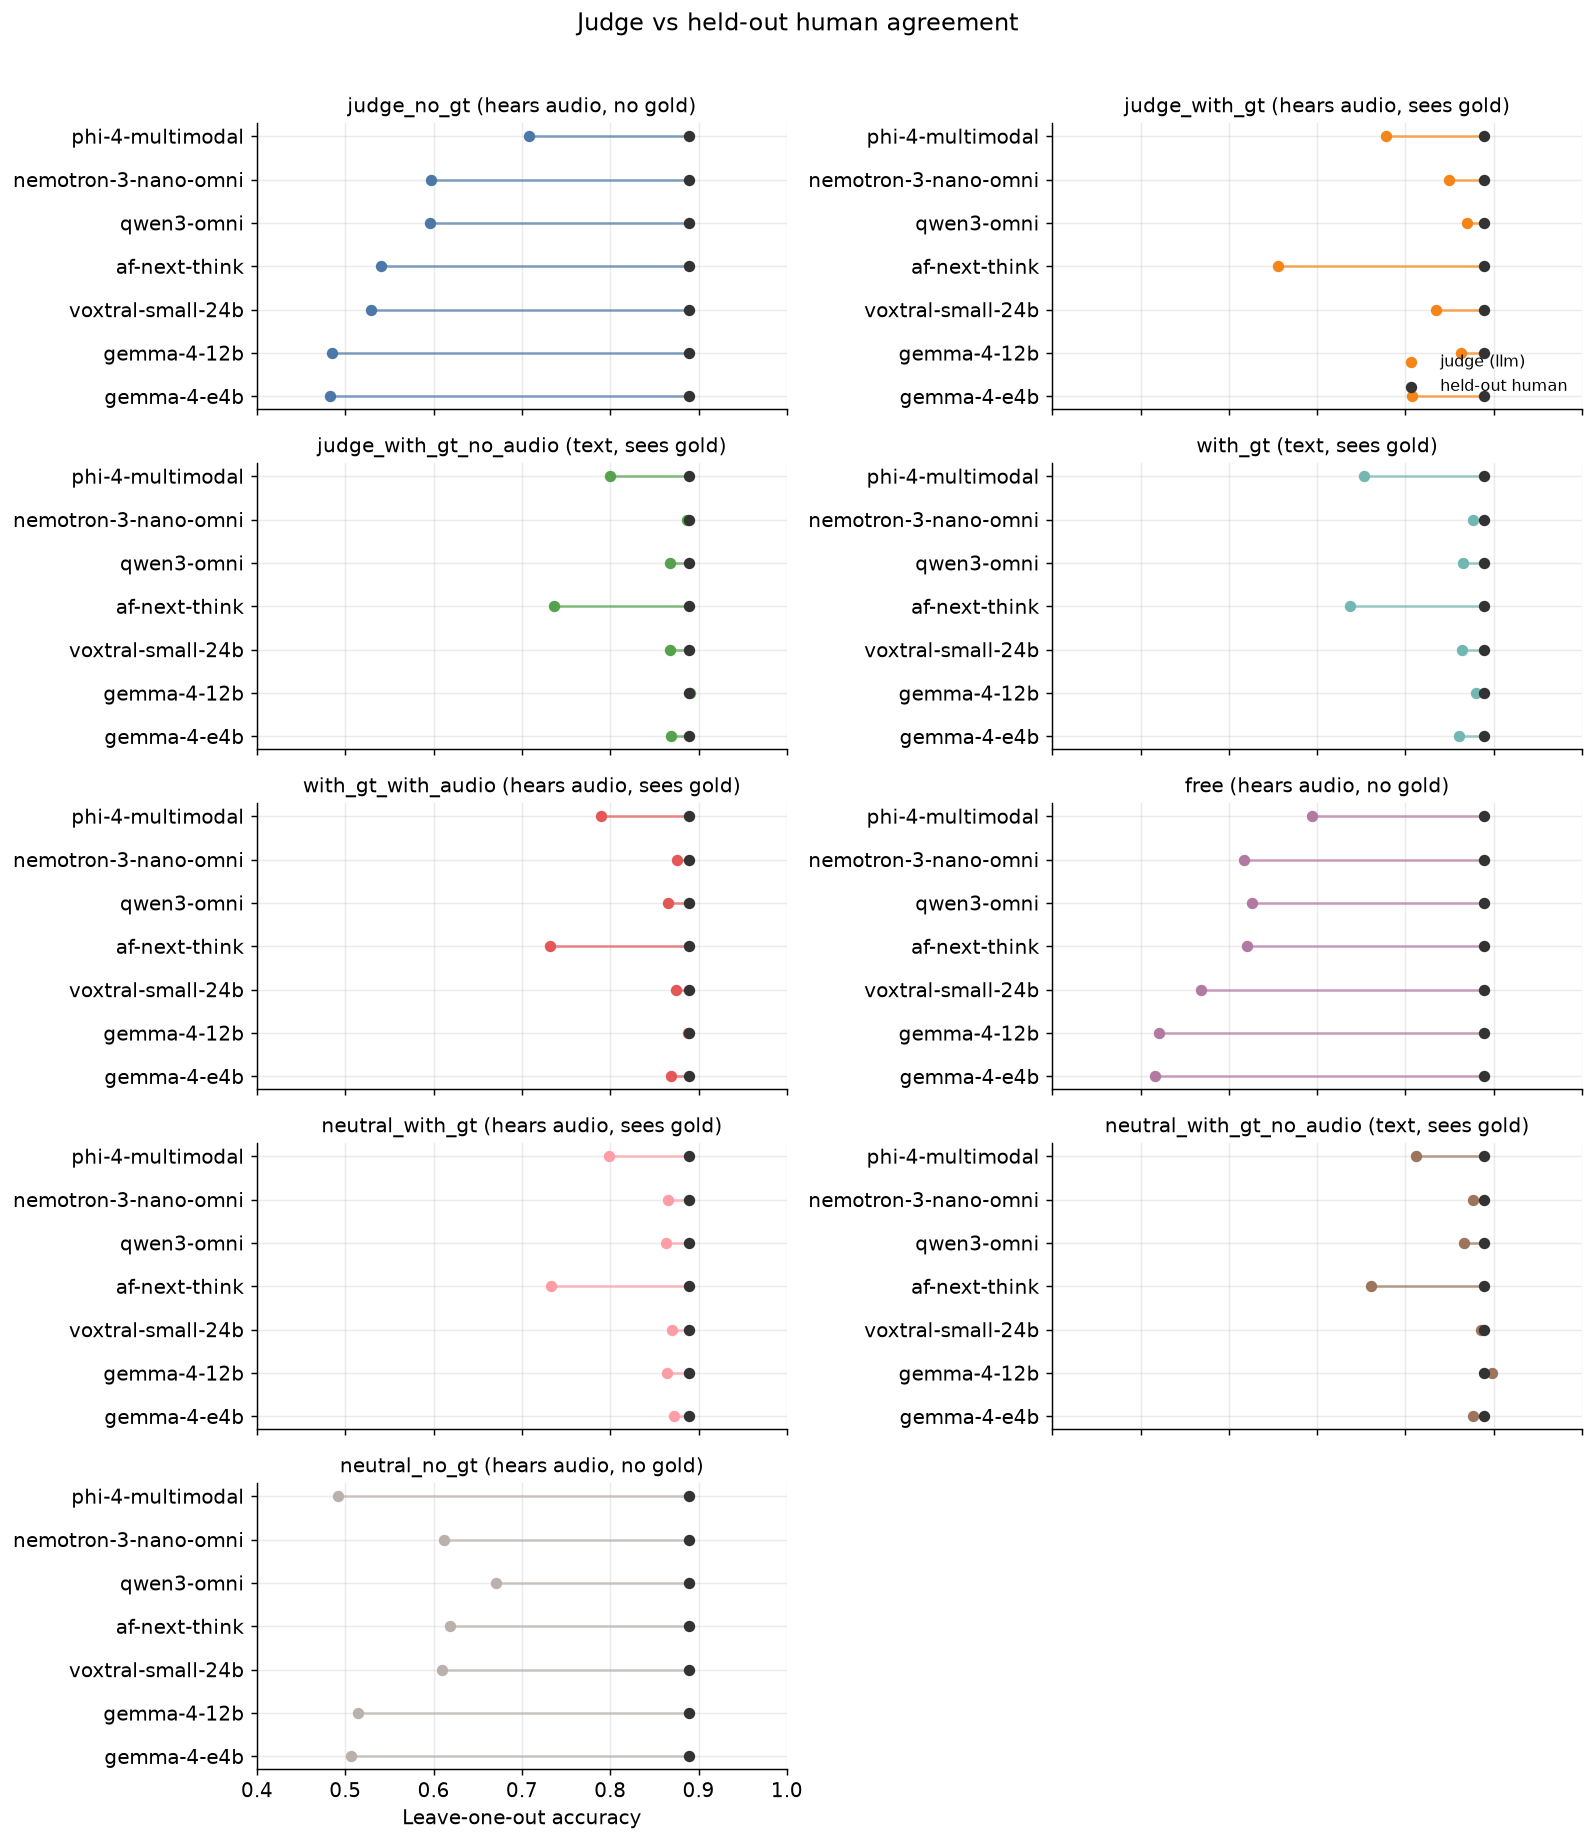

In [17]:
n_modes = len(MODE_ORDER)
ncols = 2 if n_modes > 1 else 1
nrows = int(np.ceil(n_modes / ncols))
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(6.2 * ncols, 0.36 * len(model_order) * nrows + 1.4),
    sharex=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, mode in zip(axes, MODE_ORDER):
    sub = df[df["mode"] == mode].set_index("model").reindex(model_order)
    y = np.arange(len(model_order))
    llm = sub["llm"].to_numpy(dtype=float)
    hum = sub["hum"].to_numpy(dtype=float)
    color = MODE_COLORS.get(mode, "#4C78A8")
    for yi, a, b in zip(y, llm, hum):
        if np.isnan(a) or np.isnan(b):
            continue
        ax.plot([a, b], [yi, yi], color=color, linewidth=1.4, alpha=0.7)
    ax.scatter(llm, y, color=color, s=28, zorder=3, label="judge (llm)")
    ax.scatter(hum, y, color="#333333", s=28, zorder=3, label="held-out human")
    ax.set_yticks(y)
    ax.set_yticklabels(model_order)
    ax.set_title(grade_mode_title(mode), fontsize=11)
    ax.set_xlim(0.4, 1.0)
    ax.invert_yaxis()

for ax in axes[n_modes:]:
    ax.set_visible(False)

axes[min(1, n_modes - 1)].legend(loc="lower right", fontsize=9, frameon=False)
for ax in axes[(nrows - 1) * ncols :]:
    if ax.get_visible():
        ax.set_xlabel("Leave-one-out accuracy")
fig.suptitle("Judge vs held-out human agreement", y=1.01)
fig.tight_layout()
plt.show()

## Gold vs no-gold, and audio vs text with gold

Left: ρ drop when the gold answer is removed (`with_gt` → `free`). Right: ρ change when audio is removed from a gold-supplied neutral prompt. The audio ablation should be small if the reference, not the clip, is doing the work.


,ρ left,ρ right,Δρ
model,,,
phi-4-multimodal,0.832,0.774,0.058
nemotron-3-nano-omni,0.951,0.699,0.252
qwen3-omni,0.940,0.710,0.230
af-next-think,0.816,0.702,0.114
voxtral-small-24b,0.939,0.649,0.290
gemma-4-12b,0.955,0.603,0.352
gemma-4-e4b,0.935,0.598,0.337


,ρ left,ρ right,Δρ
model,,,
phi-4-multimodal,0.876,0.888,-0.012
nemotron-3-nano-omni,0.940,0.952,-0.012
qwen3-omni,0.938,0.942,-0.003
af-next-think,0.810,0.839,-0.029
voxtral-small-24b,0.944,0.960,-0.016
gemma-4-12b,0.940,0.972,-0.032
gemma-4-e4b,0.945,0.950,-0.005


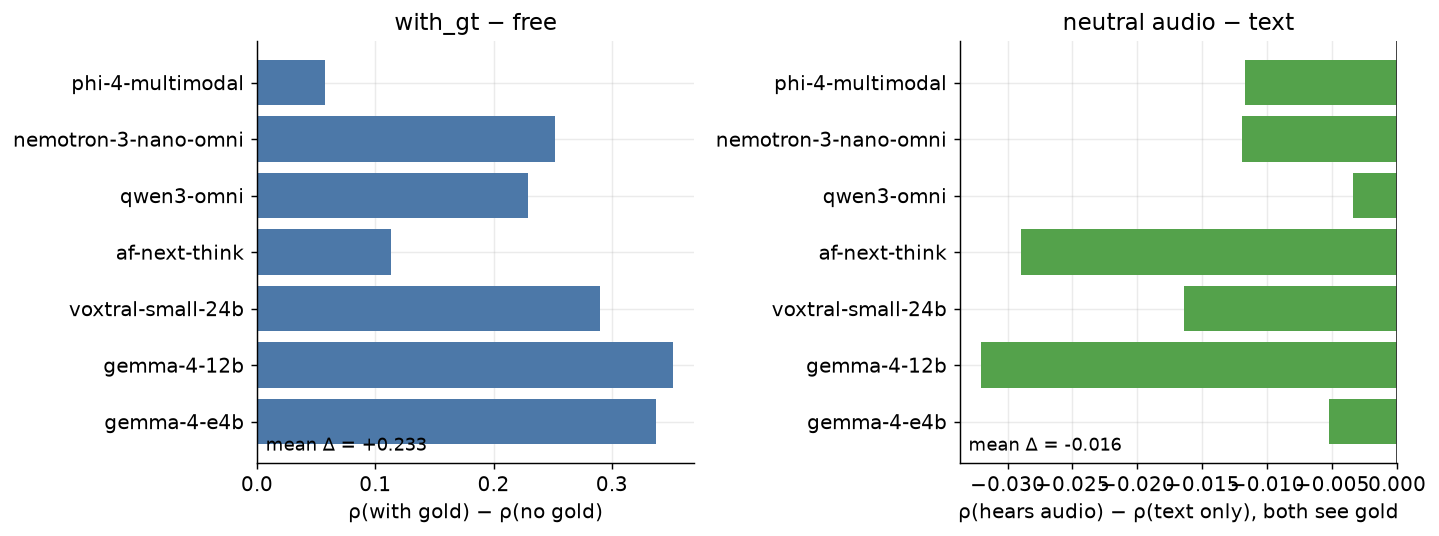

In [18]:
def paired_delta(left: str, right: str) -> pd.DataFrame:
    a = df[df["mode"] == left].set_index("model")["rho"]
    b = df[df["mode"] == right].set_index("model")["rho"]
    both = a.index.intersection(b.index)
    out = pd.DataFrame({"left": a.loc[both], "right": b.loc[both]})
    out["delta"] = out["left"] - out["right"]
    return out.reindex([m for m in model_order if m in out.index])


pairs = []
if "with_gt" in MODE_ORDER and "free" in MODE_ORDER:
    pairs.append(
        (
            "with_gt − free",
            "ρ(with gold) − ρ(no gold)",
            paired_delta("with_gt", "free"),
            "#4C78A8",
        )
    )
if "neutral_with_gt" in MODE_ORDER and "neutral_with_gt_no_audio" in MODE_ORDER:
    pairs.append(
        (
            "neutral audio − text",
            "ρ(hears audio) − ρ(text only), both see gold",
            paired_delta("neutral_with_gt", "neutral_with_gt_no_audio"),
            "#54A24B",
        )
    )

if not pairs:
    print("No paired modes to compare.")
else:
    fig, axes = plt.subplots(1, len(pairs), figsize=(5.6 * len(pairs), 0.38 * len(model_order) + 1.6))
    axes = np.atleast_1d(axes)
    for ax, (title, xlabel, table, color) in zip(axes, pairs):
        y = np.arange(len(table))
        ax.barh(y, table["delta"].to_numpy(dtype=float), color=color)
        ax.axvline(0, color="#333333", linewidth=1)
        ax.set_yticks(y)
        ax.set_yticklabels(table.index)
        ax.set_xlabel(xlabel)
        ax.set_title(title)
        ax.invert_yaxis()
        mean = float(table["delta"].mean())
        ax.text(
            0.02,
            0.02,
            f"mean Δ = {mean:+.3f}",
            transform=ax.transAxes,
            fontsize=10,
            va="bottom",
        )
        display(table.rename(columns={"left": "ρ left", "right": "ρ right", "delta": "Δρ"}).round(3))
    fig.tight_layout()
    plt.show()

## Majority-vote panel and effective votes

Each prompt is scored again as **one** judge: every model that has that prompt casts a vote, and the panel label is the strict majority of parsed `pass`/`fail` verdicts. Unparsed replies abstain. A tie (or no parsed votes) is the same disagreement token used for unparsed individuals — it never matches a human label. Dropped models (`DROPPED_MODEL_LABELS`, currently Qwen 2.5 Omni) are excluded from panel membership, individual baselines, and plots.

ρ, ω, and the leave-one-out columns use the same `score_binary_judge` path as the per-model tables above. If pooling recovered the no-gold gap, the `free` / `neutral_no_gt` panels would approach the gold-prompt ρ.

Following Kohli (2026), *Nine Judges, Two Effective Votes* ([arXiv:2605.29800](https://arxiv.org/abs/2605.29800)), effective votes are estimated from each judge's binary error vector relative to the three-human majority label. On the complete-case items where every panel member emitted a parsed verdict, pairwise phi is Pearson correlation between binary error vectors. The Kish estimate is

$$n_{\mathrm{eff}} = \frac{k}{1 + (k - 1)\bar{\phi}},$$

where $k$ is the nominal panel size and $\bar{\phi}$ is mean pairwise error correlation. $n_{\mathrm{eff}}=k$ indicates independent errors; values near 1 indicate nearly redundant votes. The complete-case count is reported because the cited paper's formula assumes a common error vector across judges.


In [19]:
from collections import defaultdict

from aggregate import DROPPED_MODEL_LABELS, is_dropped_model
from alt_test import UNPARSED, majority_label, score_binary_judge
from grader import parse_judge_key
from run_judges import (
    LABELS_CSV_NAME,
    load_pack_label_rows,
    _entry_correct,
    _instance_id,
    _judge_mode_bucket,
    _load_predictions_by_id,
    _shot_for_index,
)


def load_judge_samples(pack_dir):
    rows = load_pack_label_rows(pack_dir / LABELS_CSV_NAME)
    pred_cache: dict[str, dict] = {}
    samples: list[tuple[str, list[bool], dict[str, dict] | None]] = []
    judge_keys: set[str] = set()
    for row in rows:
        model = row["model_label"]
        if is_dropped_model(model):
            continue
        qid = row["question_id"]
        if model not in pred_cache:
            pred_cache[model] = _load_predictions_by_id(
                pack_dir / "models" / model / "predictions.jsonl"
            )
        record = pred_cache[model].get(qid)
        shot = _shot_for_index(record, row["shot_index"]) if record else None
        judges = None
        if shot is not None and isinstance(shot.get("judges"), dict):
            judges = {
                str(key): dict(entry)
                for key, entry in shot["judges"].items()
                if key and not is_dropped_model(str(key))
            }
            judge_keys.update(judges)
        samples.append((_instance_id(row), list(row["ratings"]), judges))

    key_mode: dict[str, str] = {}
    for key in sorted(judge_keys):
        sample_entry = next(
            (
                (judges or {}).get(key)
                for _iid, _ratings, judges in samples
                if judges and key in judges
            ),
            None,
        )
        mode = _judge_mode_bucket(
            key, sample_entry if isinstance(sample_entry, dict) else None
        )
        if mode is not None:
            key_mode[key] = mode
    return samples, key_mode


def panel_annotation(votes: list) -> object:
    if not votes:
        return None
    majority = majority_label([value for value in votes if isinstance(value, bool)])
    return majority if majority is not None else UNPARSED


PANEL_EXCLUDED_MODELS = set(DROPPED_MODEL_LABELS)


def kish_effective_votes(error_rows: list[dict], keys: list[str]) -> dict:
    """Kish n_eff from complete-case binary judge-error vectors."""
    errors = pd.DataFrame(error_rows, columns=keys, dtype=float).dropna(axis=0, how="any")
    k = len(keys)
    if k < 2 or len(errors) < 2:
        return {"n_eff_items": len(errors), "mean_phi": np.nan, "n_eff": np.nan}
    corr = errors.corr(method="pearson").to_numpy(dtype=float)
    mean_phi = float(corr[np.triu_indices(k, k=1)].mean())
    n_eff = k / (1 + (k - 1) * mean_phi)
    return {"n_eff_items": len(errors), "mean_phi": mean_phi, "n_eff": n_eff}


samples, key_mode = load_judge_samples(LOCAL_PACK_DIR)
keys_by_mode: dict[str, list[str]] = defaultdict(list)
for key, mode in key_mode.items():
    judge_model = parse_judge_key(key).get("model") or key
    if judge_model not in PANEL_EXCLUDED_MODELS:
        keys_by_mode[mode].append(key)

panel_individual_df = df[
    ~df["model"].map(str).isin(PANEL_EXCLUDED_MODELS)
].copy()

print(f"Panel membership (excluding {', '.join(sorted(PANEL_EXCLUDED_MODELS)) or 'none'})")
for mode in MODE_ORDER:
    keys = keys_by_mode.get(mode, [])
    models = [parse_judge_key(key).get("model") or key for key in keys]
    print(f"  {grade_mode_title(mode)}: {len(models)} ({', '.join(models)})")

epsilon = float(payload["epsilon"])
panel_rows = []
for mode in MODE_ORDER:
    keys = keys_by_mode.get(mode, [])
    if not keys:
        continue
    instances = []
    error_rows: list[dict[str, float]] = []
    n_present = 0
    n_majority = 0
    n_tie = 0
    n_votes: list[int] = []
    for instance_id, ratings, judges in samples:
        votes = []
        errors: dict[str, float] = {}
        human_majority = majority_label(ratings)
        for key in keys:
            entry = (judges or {}).get(key)
            vote = _entry_correct(entry) if isinstance(entry, dict) else None
            if isinstance(vote, bool):
                votes.append(vote)
                if isinstance(human_majority, bool):
                    errors[key] = float(vote != human_majority)
        error_rows.append(errors)
        pred = panel_annotation(votes)
        instances.append((instance_id, ratings, pred))
        if not votes:
            continue
        n_present += 1
        n_votes.append(sum(isinstance(value, bool) for value in votes))
        if isinstance(pred, bool):
            n_majority += 1
        else:
            n_tie += 1
    stats = score_binary_judge(instances, epsilon=epsilon)
    effective = kish_effective_votes(error_rows, keys)
    individuals = panel_individual_df[panel_individual_df["mode"] == mode]
    mean_rho = float(individuals["rho"].mean()) if len(individuals) else np.nan
    max_rho = float(individuals["rho"].max()) if len(individuals) else np.nan
    rho = stats.get("advantage_prob")
    panel_rows.append(
        {
            "mode": mode,
            "mode_title": grade_mode_title(mode),
            "n_judges": len(keys),
            **effective,
            "independence_ratio": effective["n_eff"] / len(keys),
            "n": stats.get("n"),
            "n_missing": stats.get("n_missing"),
            "n_tie": n_tie,
            "parse_rate": (n_majority / n_present) if n_present else None,
            "mean_votes": float(np.mean(n_votes)) if n_votes else None,
            "rho": rho,
            "rho_lo": stats.get("advantage_prob_ci_low"),
            "rho_hi": stats.get("advantage_prob_ci_high"),
            "llm": stats.get("loo_agree_judge"),
            "hum": stats.get("loo_agree_human"),
            "omega": stats.get("winning_rate"),
            "passed": stats.get("passed"),
            "mean_rho": mean_rho,
            "max_rho": max_rho,
            "delta_mean": None if rho is None else rho - mean_rho,
            "delta_best": None if rho is None else rho - max_rho,
        }
    )

panel_df = pd.DataFrame(panel_rows)
if panel_df.empty:
    raise SystemExit("No majority-vote panels to score")

print("Majority-vote panel (same columns as --accuracy-only, plus vs individuals)")
display(
    panel_df[
        [
            "mode",
            "n_judges",
            "n_eff_items",
            "mean_phi",
            "n_eff",
            "independence_ratio",
            "n",
            "n_missing",
            "n_tie",
            "parse_rate",
            "mean_votes",
            "rho",
            "rho_lo",
            "rho_hi",
            "llm",
            "hum",
            "omega",
            "passed",
            "mean_rho",
            "max_rho",
            "delta_mean",
            "delta_best",
        ]
    ].style.format(
        {
            "mean_phi": "{:.3f}",
            "n_eff": "{:.2f}",
            "independence_ratio": "{:.1%}",
            "parse_rate": "{:.3f}",
            "mean_votes": "{:.2f}",
            "rho": "{:.3f}",
            "rho_lo": "{:.3f}",
            "rho_hi": "{:.3f}",
            "llm": "{:.3f}",
            "hum": "{:.3f}",
            "omega": "{:.3f}",
            "mean_rho": "{:.3f}",
            "max_rho": "{:.3f}",
            "delta_mean": "{:+.3f}",
            "delta_best": "{:+.3f}",
        },
        na_rep="—",
    )
)


Panel membership (excluding qwen2.5-omni-7b)
  judge_no_gt (hears audio, no gold): 7 (af-next-think, gemma-4-12b, gemma-4-e4b, nemotron-3-nano-omni, phi-4-multimodal, qwen3-omni, voxtral-small-24b)
  judge_with_gt (hears audio, sees gold): 7 (af-next-think, gemma-4-12b, gemma-4-e4b, nemotron-3-nano-omni, phi-4-multimodal, qwen3-omni, voxtral-small-24b)
  judge_with_gt_no_audio (text, sees gold): 7 (af-next-think, gemma-4-12b, gemma-4-e4b, nemotron-3-nano-omni, phi-4-multimodal, qwen3-omni, voxtral-small-24b)
  with_gt (text, sees gold): 7 (af-next-think, gemma-4-12b, gemma-4-e4b, nemotron-3-nano-omni, phi-4-multimodal, qwen3-omni, voxtral-small-24b)
  with_gt_with_audio (hears audio, sees gold): 7 (af-next-think, gemma-4-12b, gemma-4-e4b, nemotron-3-nano-omni, phi-4-multimodal, qwen3-omni, voxtral-small-24b)
  free (hears audio, no gold): 7 (af-next-think, gemma-4-12b, gemma-4-e4b, nemotron-3-nano-omni, phi-4-multimodal, qwen3-omni, voxtral-small-24b)
  neutral_with_gt (hears audio, se

,mode,n_judges,n_eff_items,mean_phi,n_eff,independence_ratio,n,n_missing,n_tie,parse_rate,mean_votes,rho,rho_lo,rho_hi,llm,hum,omega,passed,mean_rho,max_rho,delta_mean,delta_best
0,judge_no_gt,7,4269,0.212,3.08,44.0%,3834,0,54,0.988,6.94,0.646,0.604,0.684,0.564,0.889,0.000,False,0.645,0.788,+0.001,-0.142
1,judge_with_gt,7,4260,0.276,2.64,37.7%,3834,0,16,0.996,6.94,0.954,0.936,0.969,0.880,0.889,1.000,True,0.885,0.945,+0.069,+0.009
2,judge_with_gt_no_audio,7,4518,0.411,2.02,28.9%,3834,0,3,0.999,6.99,0.962,0.945,0.976,0.888,0.889,1.000,True,0.921,0.965,+0.041,-0.003
3,with_gt,7,4410,0.440,1.92,27.5%,3834,0,9,0.998,6.97,0.954,0.939,0.968,0.879,0.889,1.000,True,0.910,0.955,+0.044,-0.001
4,with_gt_with_audio,7,4378,0.473,1.82,26.1%,3834,0,5,0.999,6.96,0.959,0.946,0.972,0.884,0.889,1.000,True,0.918,0.963,+0.041,-0.004
5,free,7,4426,0.184,3.33,47.6%,3834,0,26,0.994,6.97,0.703,0.665,0.740,0.622,0.889,0.000,False,0.676,0.774,+0.027,-0.071
6,neutral_with_gt,7,4415,0.353,2.24,32.0%,3834,0,9,0.998,6.97,0.965,0.954,0.976,0.892,0.889,1.000,True,0.914,0.945,+0.052,+0.020
7,neutral_with_gt_no_audio,7,4498,0.450,1.89,27.0%,3834,0,0,1.000,6.99,0.966,0.952,0.978,0.893,0.889,1.000,True,0.929,0.972,+0.037,-0.006
8,neutral_no_gt,7,4348,0.285,2.58,36.9%,3834,0,32,0.993,6.96,0.686,0.649,0.724,0.603,0.889,0.000,False,0.657,0.753,+0.029,-0.067


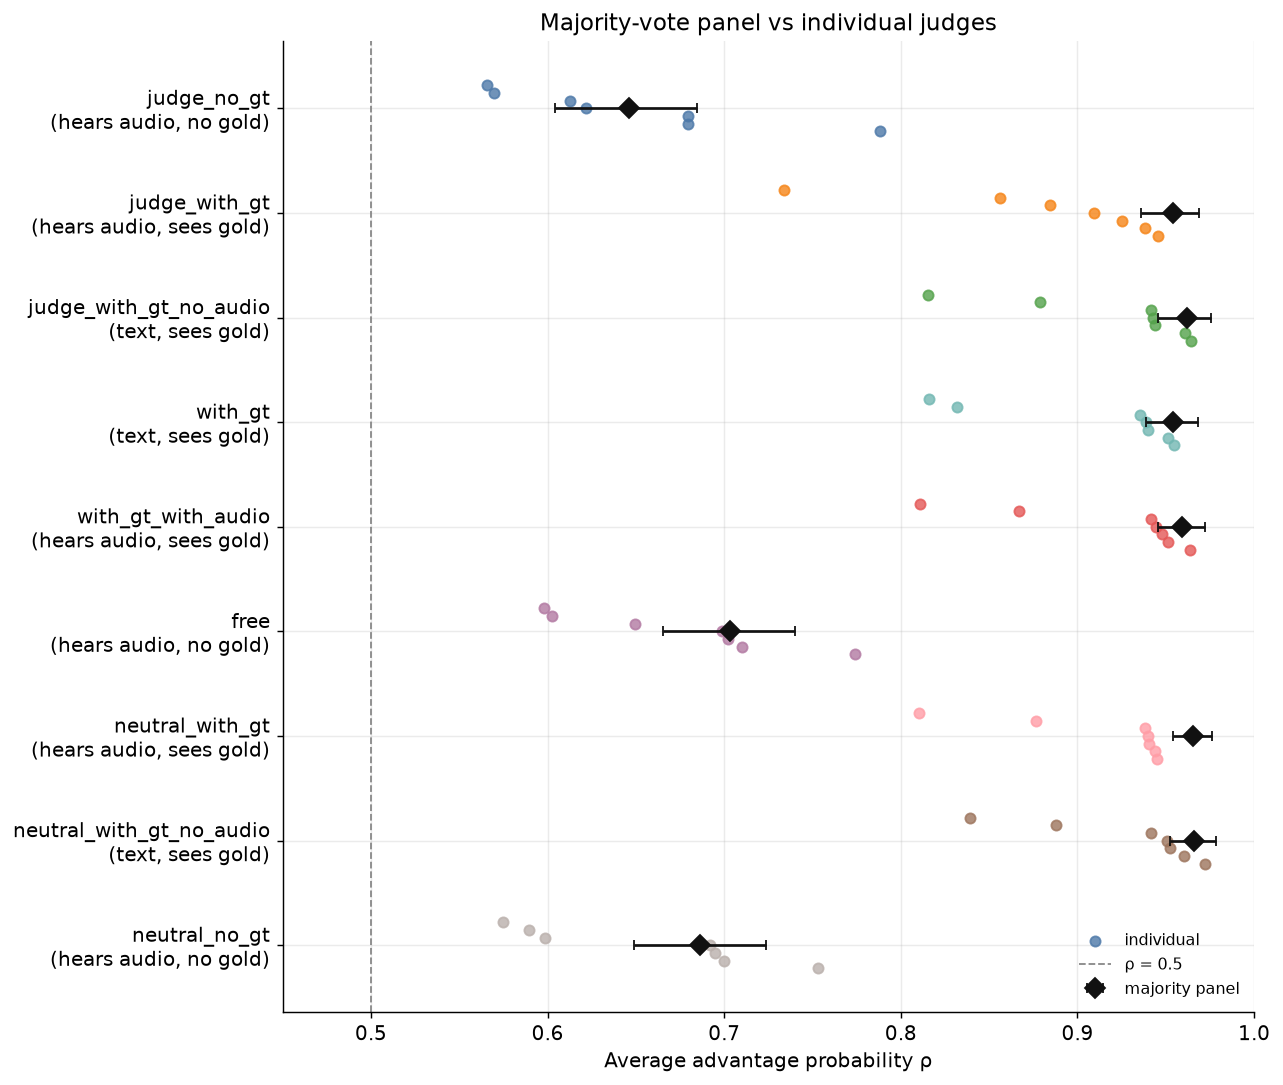

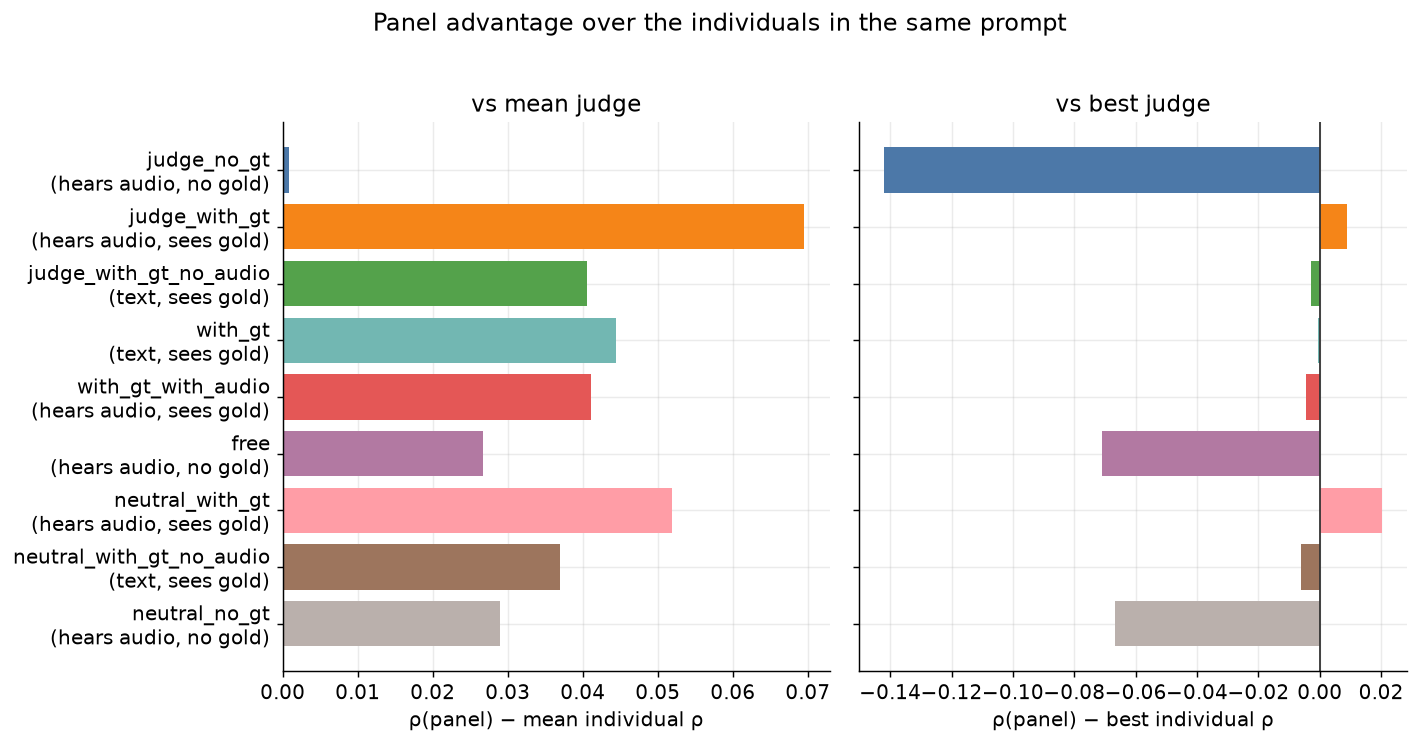

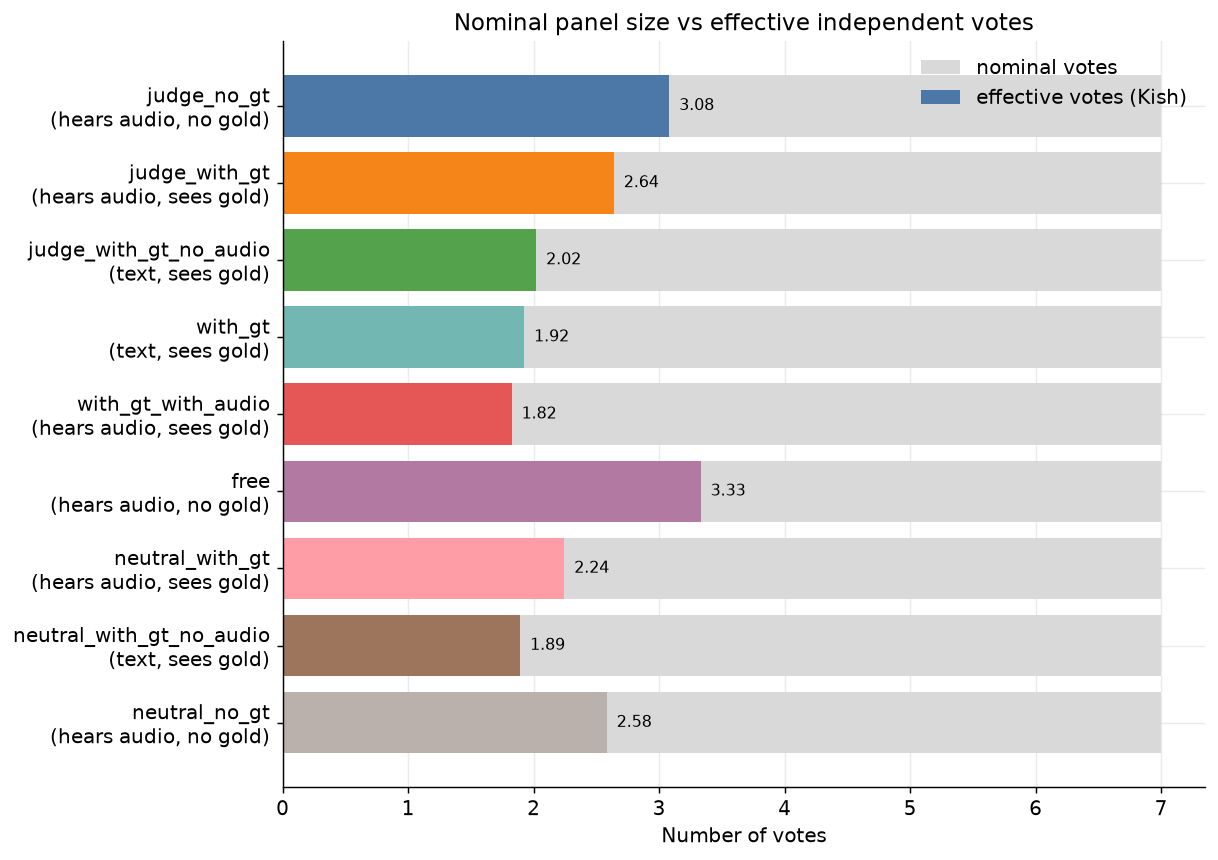

In [20]:
fig, ax = plt.subplots(figsize=(10, 0.72 * len(MODE_ORDER) + 2.0))
for i, mode in enumerate(MODE_ORDER):
    sub = panel_individual_df[panel_individual_df["mode"] == mode].sort_values("rho")
    n = len(sub)
    ypos = np.full(n, i, dtype=float) if n <= 1 else i + np.linspace(-0.22, 0.22, n)
    ax.scatter(
        sub["rho"].to_numpy(dtype=float),
        ypos,
        color=MODE_COLORS.get(mode, "#4C78A8"),
        s=32,
        alpha=0.8,
        zorder=3,
        label="individual" if i == 0 else None,
    )
row = panel_df.set_index("mode").reindex(MODE_ORDER)
x = row["rho"].to_numpy(dtype=float)
lo = row["rho_lo"].to_numpy(dtype=float)
hi = row["rho_hi"].to_numpy(dtype=float)
y = np.arange(len(MODE_ORDER), dtype=float)
ok = np.isfinite(x)
xerr = np.vstack(
    [
        np.clip(x - lo, 0, None),
        np.clip(hi - x, 0, None),
    ]
)
ax.errorbar(
    x[ok],
    y[ok],
    xerr=xerr[:, ok],
    fmt="D",
    color="#111111",
    ms=8,
    capsize=3,
    zorder=4,
    label="majority panel",
)
ax.set_yticks(y)
ax.set_yticklabels([mode_label(mode) for mode in MODE_ORDER])
ax.set_xlabel("Average advantage probability ρ")
ax.set_xlim(0.45, 1.0)
ax.axvline(0.5, color="#888888", linewidth=1, linestyle="--", label="ρ = 0.5")
ax.set_title("Majority-vote panel vs individual judges")
ax.legend(loc="lower right", fontsize=9, frameon=False)
ax.invert_yaxis()
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11.2, 0.42 * len(panel_df) + 1.8), sharey=True)
y = np.arange(len(panel_df))
for ax, column, xlabel, title in zip(
    axes,
    ["delta_mean", "delta_best"],
    ["ρ(panel) − mean individual ρ", "ρ(panel) − best individual ρ"],
    ["vs mean judge", "vs best judge"],
):
    values = panel_df[column].to_numpy(dtype=float)
    colors = [MODE_COLORS.get(mode, "#4C78A8") for mode in panel_df["mode"]]
    ax.barh(y, values, color=colors)
    ax.axvline(0, color="#333333", linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
axes[0].set_yticks(y)
axes[0].set_yticklabels([mode_label(mode) for mode in panel_df["mode"]])
axes[0].invert_yaxis()
fig.suptitle("Panel advantage over the individuals in the same prompt", y=1.02)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 0.55 * len(panel_df) + 1.8))
y = np.arange(len(panel_df))
ax.barh(
    y,
    panel_df["n_judges"],
    color="#D9D9D9",
    label="nominal votes",
)
ax.barh(
    y,
    panel_df["n_eff"],
    color=[MODE_COLORS.get(mode, "#4C78A8") for mode in panel_df["mode"]],
    label="effective votes (Kish)",
)
for yi, n_eff in zip(y, panel_df["n_eff"]):
    ax.text(n_eff + 0.08, yi, f"{n_eff:.2f}", va="center", fontsize=9)
ax.set_yticks(y)
ax.set_yticklabels([mode_label(mode) for mode in panel_df["mode"]])
ax.set_xlabel("Number of votes")
ax.set_title("Nominal panel size vs effective independent votes")
ax.legend(frameon=False)
ax.invert_yaxis()
fig.tight_layout()
plt.show()


## Generation accuracy vs `neutral_no_gt` judging

For models in `exports/labels.csv`, generation accuracy is the fraction of **9** human ratings that are Correct (3 shots × 3 labelers). No model has three raters on every labeled generation — 27 questions have 1–2 ratings — so the mean uses the **142** questions where all three shots have all three ratings.

That score is correlated with the same model's **majority-agreement accuracy** as a `neutral_no_gt` judge (parsed verdict vs the three-human majority on the same 142 questions). Unparsed replies never match a human majority, so they count as disagreements. Models that lack either a complete denom-9 series or a `neutral_no_gt` judge slot are listed, not plotted. Dropped models (`DROPPED_MODEL_LABELS`) are omitted.


In [21]:
from collections import defaultdict

from scipy.stats import pearsonr, spearmanr

from aggregate import is_dropped_model
from alt_test import majority_label
from run_judges import (
    EXPORTS_DIR,
    LABELS_CSV_NAME,
    load_pack_label_rows,
    _entry_correct,
    _judge_mode_bucket,
    _load_predictions_by_id,
    _shot_for_index,
)

N_SHOTS = 3
N_LABELERS = 3
DENOM = N_SHOTS * N_LABELERS
JUDGE_MODE = "neutral_no_gt"

label_rows = [
    row
    for row in load_pack_label_rows(EXPORTS_DIR / LABELS_CSV_NAME)
    if not is_dropped_model(row["model_label"])
]
by_model_q: dict[str, dict[str, list]] = defaultdict(lambda: defaultdict(list))
for row in label_rows:
    by_model_q[row["model_label"]][row["question_id"]].append(row)

gen_rows = []
partial_models = []
for model, by_q in sorted(by_model_q.items()):
    full = []
    for items in by_q.values():
        if len(items) == N_SHOTS and all(len(item["ratings"]) == N_LABELERS for item in items):
            full.append(items)
    n_q = len(full)
    n_all_q = len(by_q)
    if n_q == 0:
        partial_models.append(model)
        continue
    n_true = sum(sum(item["ratings"]) for items in full for item in items)
    gen_rows.append(
        {
            "model": model,
            "n_questions": n_q,
            "n_partial_questions": n_all_q - n_q,
            "n_true": int(n_true),
            "gen_acc": n_true / (n_q * DENOM),
        }
    )

gen_df = pd.DataFrame(gen_rows)


def _load_judge_samples(pack_dir):
    pred_cache: dict[str, dict] = {}
    samples = []
    judge_keys: set[str] = set()
    for row in label_rows:
        model = row["model_label"]
        qid = row["question_id"]
        if model not in pred_cache:
            pred_cache[model] = _load_predictions_by_id(
                pack_dir / "models" / model / "predictions.jsonl"
            )
        record = pred_cache[model].get(qid)
        shot = _shot_for_index(record, row["shot_index"]) if record else None
        judges = None
        if shot is not None and isinstance(shot.get("judges"), dict):
            judges = {
                str(key): dict(entry)
                for key, entry in shot["judges"].items()
                if key and not is_dropped_model(str(key))
            }
            judge_keys.update(judges)
        samples.append((list(row["ratings"]), judges))
    key_mode = {}
    for key in sorted(judge_keys):
        sample_entry = next(
            (
                judges.get(key)
                for _ratings, judges in samples
                if judges and key in judges
            ),
            None,
        )
        mode = _judge_mode_bucket(
            key, sample_entry if isinstance(sample_entry, dict) else None
        )
        if mode is not None:
            key_mode[key] = mode
    return samples, key_mode


if "samples" in globals() and "key_mode" in globals():
    judge_samples = [
        (ratings, judges) for _iid, ratings, judges in samples
    ]
    judge_key_mode = {
        key: mode
        for key, mode in key_mode.items()
        if not is_dropped_model(key)
    }
else:
    judge_samples, judge_key_mode = _load_judge_samples(LOCAL_PACK_DIR)

nng_keys = [key for key, mode in judge_key_mode.items() if mode == JUDGE_MODE]
judge_rows = []
for key in sorted(nng_keys):
    model = parse_judge_key(key).get("model") or key
    n = 0
    n_agree = 0
    n_parsed = 0
    n_parsed_agree = 0
    n_unparsed = 0
    for ratings, judges in judge_samples:
        if len(ratings) < N_LABELERS:
            continue
        gold = majority_label(ratings)
        if gold is None:
            continue
        entry = (judges or {}).get(key)
        pred = _entry_correct(entry) if isinstance(entry, dict) else None
        if pred is None:
            continue
        n += 1
        if isinstance(pred, bool):
            n_parsed += 1
            if pred == gold:
                n_agree += 1
                n_parsed_agree += 1
        else:
            n_unparsed += 1
    judge_rows.append(
        {
            "model": model,
            "n_judge": n,
            "n_unparsed": n_unparsed,
            "judge_acc": (n_agree / n) if n else None,
            "judge_acc_parsed": (n_parsed_agree / n_parsed) if n_parsed else None,
        }
    )

judge_df = pd.DataFrame(judge_rows)
alt = df.loc[df["mode"] == JUDGE_MODE, ["model", "llm", "rho", "parse_rate"]].copy()
alt["model"] = alt["model"].astype(str)
corr_df = gen_df.merge(judge_df, on="model", how="inner").merge(alt, on="model", how="left")
corr_df = corr_df.sort_values("gen_acc").reset_index(drop=True)

labeled_models = set(gen_df["model"])
nng_models = set(judge_df["model"]) if len(judge_df) else set()
print(
    f"denom-9 questions: {int(gen_df['n_questions'].iloc[0]) if len(gen_df) else 0} "
    f"(dropped {int(gen_df['n_partial_questions'].iloc[0]) if len(gen_df) else 0} with <3 raters)"
)
print(f"models with denom-9 series: {len(labeled_models)}")
print(f"models with {JUDGE_MODE} verdicts: {len(nng_models)}")
print(
    "labeled, no "
    f"{JUDGE_MODE}: {', '.join(sorted(labeled_models - nng_models)) or '—'}"
)
print(
    f"{JUDGE_MODE}, no labels: {', '.join(sorted(nng_models - labeled_models)) or '—'}"
)
if partial_models:
    print(f"no complete denom-9 series: {', '.join(partial_models)}")

if len(corr_df) < 2:
    raise SystemExit("Need at least two models with both scores")

r_pearson, p_pearson = pearsonr(corr_df["gen_acc"], corr_df["judge_acc"])
r_spearman, p_spearman = spearmanr(corr_df["gen_acc"], corr_df["judge_acc"])
print(
    f"\nPearson r = {r_pearson:.3f} (p = {p_pearson:.3f})  "
    f"Spearman ρ = {r_spearman:.3f} (p = {p_spearman:.3f})  "
    f"n = {len(corr_df)}"
)

display(
    corr_df[
        [
            "model",
            "n_questions",
            "n_true",
            "gen_acc",
            "n_judge",
            "n_unparsed",
            "judge_acc",
            "judge_acc_parsed",
            "llm",
            "rho",
            "parse_rate",
        ]
    ].style.format(
        {
            "gen_acc": "{:.3f}",
            "judge_acc": "{:.3f}",
            "judge_acc_parsed": "{:.3f}",
            "llm": "{:.3f}",
            "rho": "{:.3f}",
            "parse_rate": "{:.3f}",
        },
        na_rep="—",
    )
)


denom-9 questions: 127 (dropped 22 with <3 raters)
models with denom-9 series: 9
models with neutral_no_gt verdicts: 7
labeled, no neutral_no_gt: gemini-3.7-flash, interactive-omni-8b, mimo-audio-7b, qwen3-omni-instruct
neutral_no_gt, no labels: gemma-4-12b, nemotron-3-nano-omni

Pearson r = 0.809 (p = 0.097)  Spearman ρ = 0.900 (p = 0.037)  n = 5


,model,n_questions,n_true,gen_acc,n_judge,n_unparsed,judge_acc,judge_acc_parsed,llm,rho,parse_rate
0,phi-4-multimodal,127,209,0.183,3834,10,0.492,0.493,0.492,0.575,0.998
1,gemma-4-e4b,127,261,0.228,3834,2,0.506,0.506,0.506,0.590,1.000
2,af-next-think,127,264,0.231,3834,78,0.622,0.635,0.619,0.700,0.979
3,voxtral-small-24b,127,336,0.294,3834,2,0.612,0.613,0.610,0.692,1.000
4,qwen3-omni,127,500,0.437,3834,0,0.670,0.670,0.670,0.753,1.000


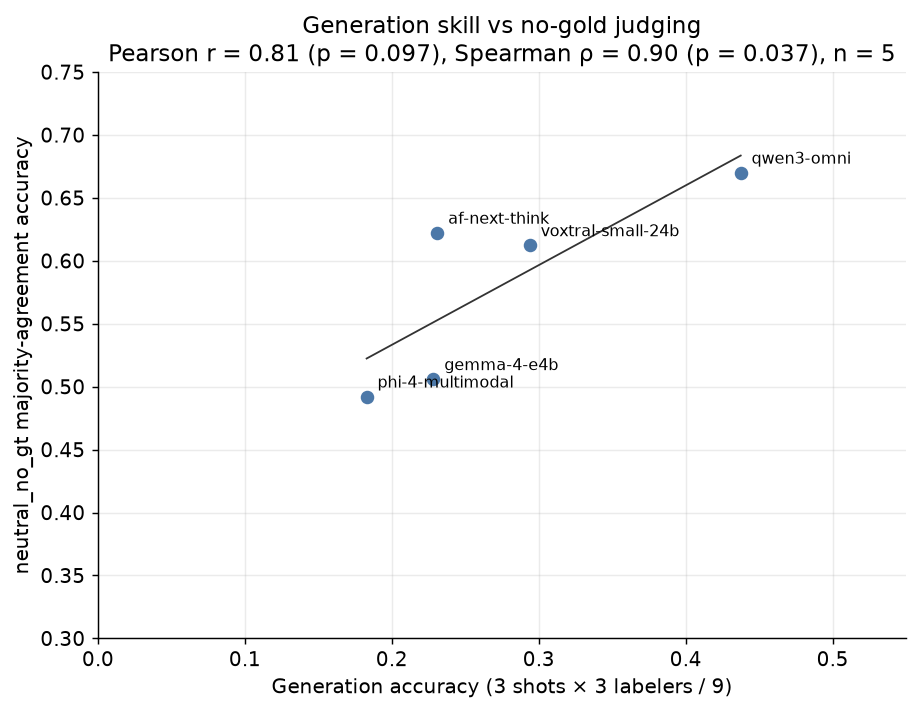

In [22]:
fig, ax = plt.subplots(figsize=(7.2, 5.6))
x = corr_df["gen_acc"].to_numpy(dtype=float)
y = corr_df["judge_acc"].to_numpy(dtype=float)
ax.scatter(x, y, s=42, color="#4C78A8", zorder=3)
for model, xi, yi in zip(corr_df["model"], x, y):
    ax.annotate(
        model,
        (xi, yi),
        textcoords="offset points",
        xytext=(6, 5),
        fontsize=9,
    )
if len(corr_df) >= 2:
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, slope * xs + intercept, color="#333333", linewidth=1, zorder=2)
ax.set_xlabel(f"Generation accuracy (3 shots × 3 labelers / {DENOM})")
ax.set_ylabel("neutral_no_gt majority-agreement accuracy")
ax.set_title(
    f"Generation skill vs no-gold judging\n"
    f"Pearson r = {r_pearson:.2f} (p = {p_pearson:.3f}), "
    f"Spearman ρ = {r_spearman:.2f} (p = {p_spearman:.3f}), n = {len(corr_df)}"
)
ax.set_xlim(0, max(0.55, float(x.max()) + 0.05))
ax.set_ylim(0.30, max(0.75, float(y.max()) + 0.05))
fig.tight_layout()
plt.show()


## Within-model, per-question: can it answer, and can it judge?

The previous scatter is one point per model. Here each point is a **question**. For model *m* on question *q*, generation accuracy is again the fraction of 9 human ratings that are Correct. Judge accuracy is *m*'s `neutral_no_gt` majority-agreement on the **other** models' labeled shots for that same question (the model's own three shots are dropped so “I got this right” is not mixed with “I graded myself correctly”).

“Can answer” is `gen_acc > 0.5` (at least five of the nine ratings True). Same 142-question, five-model intersection as above.


In [23]:
from collections import defaultdict

from scipy.stats import pearsonr, spearmanr, ttest_ind

from aggregate import is_dropped_model
from alt_test import majority_label
from run_judges import (
    EXPORTS_DIR,
    LABELS_CSV_NAME,
    load_pack_label_rows,
    _entry_correct,
    _judge_mode_bucket,
    _load_predictions_by_id,
    _shot_for_index,
)

if "N_SHOTS" not in globals():
    N_SHOTS, N_LABELERS, DENOM = 3, 3, 9
    JUDGE_MODE = "neutral_no_gt"
if "label_rows" not in globals():
    label_rows = [
        row
        for row in load_pack_label_rows(EXPORTS_DIR / LABELS_CSV_NAME)
        if not is_dropped_model(row["model_label"])
    ]
elif any(is_dropped_model(row["model_label"]) for row in label_rows):
    label_rows = [row for row in label_rows if not is_dropped_model(row["model_label"])]


def _complete_questions(rows):
    by_mq = defaultdict(lambda: defaultdict(list))
    for row in rows:
        by_mq[row["model_label"]][row["question_id"]].append(row)
    complete = None
    for by_q in by_mq.values():
        qs = {
            qid
            for qid, items in by_q.items()
            if len(items) == N_SHOTS
            and all(len(item["ratings"]) == N_LABELERS for item in items)
        }
        complete = qs if complete is None else complete & qs
    return by_mq, complete or set()


def _iter_judge_rows(rows, pack_dir):
    if "samples" in globals() and samples:
        first = samples[0]
        if len(first) == 3 and isinstance(first[0], str) and "\t" in first[0]:
            for iid, ratings, judges in samples:
                qid, gradee, shot_s = str(iid).split("\t")
                yield qid, gradee, int(shot_s), list(ratings), judges
            return
    pred_cache: dict[str, dict] = {}
    for row in rows:
        model = row["model_label"]
        qid = row["question_id"]
        if model not in pred_cache:
            pred_cache[model] = _load_predictions_by_id(
                pack_dir / "models" / model / "predictions.jsonl"
            )
        record = pred_cache[model].get(qid)
        shot = _shot_for_index(record, row["shot_index"]) if record else None
        judges = None
        if shot is not None and isinstance(shot.get("judges"), dict):
            judges = {
                str(key): dict(entry)
                for key, entry in shot["judges"].items()
                if key
            }
        yield qid, model, row["shot_index"], list(row["ratings"]), judges


def _nng_keys(judge_rows):
    if "judge_key_mode" in globals():
        return [key for key, mode in judge_key_mode.items() if mode == JUDGE_MODE]
    if "key_mode" in globals():
        return [key for key, mode in key_mode.items() if mode == JUDGE_MODE]
    keys = set()
    for *_, judges in judge_rows:
        if judges:
            keys.update(judges)
    out = []
    for key in sorted(keys):
        sample_entry = next(
            (judges.get(key) for *_, judges in judge_rows if judges and key in judges),
            None,
        )
        mode = _judge_mode_bucket(
            key, sample_entry if isinstance(sample_entry, dict) else None
        )
        if mode == JUDGE_MODE:
            out.append(key)
    return out


by_mq, complete_q = _complete_questions(label_rows)
judge_iter = list(_iter_judge_rows(label_rows, LOCAL_PACK_DIR))
nng_keys_q = _nng_keys(judge_iter)

gen_acc_q = {}
for model, by_q in by_mq.items():
    for qid in complete_q:
        items = by_q[qid]
        n_true = sum(sum(item["ratings"]) for item in items)
        gen_acc_q[(model, qid)] = n_true / DENOM

q_rows = []
for key in sorted(nng_keys_q):
    judge_model = parse_judge_key(key).get("model") or key
    if judge_model not in by_mq:
        continue
    by_q_stats = defaultdict(lambda: dict(n=0, agree=0, n_oth=0, agree_oth=0))
    for qid, gradee, _shot, ratings, judges in judge_iter:
        if qid not in complete_q:
            continue
        gold = majority_label(ratings)
        if gold is None:
            continue
        pred = (
            _entry_correct((judges or {}).get(key))
            if judges and key in (judges or {})
            else None
        )
        if pred is None:
            continue
        correct = isinstance(pred, bool) and pred == gold
        st = by_q_stats[qid]
        st["n"] += 1
        st["agree"] += int(correct)
        if gradee != judge_model:
            st["n_oth"] += 1
            st["agree_oth"] += int(correct)
    for qid, st in by_q_stats.items():
        q_rows.append(
            {
                "model": judge_model,
                "question_id": qid,
                "gen_acc": gen_acc_q[(judge_model, qid)],
                "judge_acc": (st["agree"] / st["n"]) if st["n"] else np.nan,
                "judge_acc_others": (
                    (st["agree_oth"] / st["n_oth"]) if st["n_oth"] else np.nan
                ),
                "n_judge": st["n"],
                "n_others": st["n_oth"],
                "can_answer": gen_acc_q[(judge_model, qid)] > 0.5,
            }
        )

q_df = pd.DataFrame(q_rows)
if q_df.empty:
    raise SystemExit("No per-question judge/generation pairs")

per_model = []
for model, sub in q_df.groupby("model", sort=True):
    s = sub.dropna(subset=["gen_acc", "judge_acc_others"])
    r, p = pearsonr(s["gen_acc"], s["judge_acc_others"])
    rs, ps = spearmanr(s["gen_acc"], s["judge_acc_others"])
    r_all, p_all = pearsonr(s["gen_acc"], s["judge_acc"])
    can = s.loc[s["can_answer"], "judge_acc_others"]
    cant = s.loc[~s["can_answer"], "judge_acc_others"]
    t_stat, t_p = ttest_ind(can, cant, equal_var=False) if len(can) and len(cant) else (np.nan, np.nan)
    per_model.append(
        {
            "model": model,
            "n_questions": len(s),
            "n_can": int(len(can)),
            "n_cant": int(len(cant)),
            "r": r,
            "p": p,
            "spearman": rs,
            "spearman_p": ps,
            "r_incl_self": r_all,
            "judge_can": float(can.mean()) if len(can) else np.nan,
            "judge_cant": float(cant.mean()) if len(cant) else np.nan,
            "delta": (
                float(can.mean() - cant.mean()) if len(can) and len(cant) else np.nan
            ),
            "ttest_p": t_p,
        }
    )

per_model_df = pd.DataFrame(per_model)
pooled = q_df.dropna(subset=["gen_acc", "judge_acc_others"])
r_pool, p_pool = pearsonr(pooled["gen_acc"], pooled["judge_acc_others"])
rs_pool, ps_pool = spearmanr(pooled["gen_acc"], pooled["judge_acc_others"])
print(
    f"per-question pairs: {len(q_df)}  models: {q_df['model'].nunique()}  "
    f"questions: {q_df['question_id'].nunique()}"
)
print(
    f"pooled (exclude self) Pearson r = {r_pool:.3f} (p = {p_pool:.3g})  "
    f"Spearman ρ = {rs_pool:.3f} (p = {ps_pool:.3g})"
)
print("judge_acc_others = majority agreement on other models' shots for that question")

display(
    per_model_df.style.format(
        {
            "r": "{:.3f}",
            "p": "{:.3g}",
            "spearman": "{:.3f}",
            "spearman_p": "{:.3g}",
            "r_incl_self": "{:.3f}",
            "judge_can": "{:.3f}",
            "judge_cant": "{:.3f}",
            "delta": "{:+.3f}",
            "ttest_p": "{:.3g}",
        },
        na_rep="—",
    )
)


per-question pairs: 635  models: 5  questions: 127
pooled (exclude self) Pearson r = 0.449 (p = 7.54e-33)  Spearman ρ = 0.433 (p = 1.99e-30)
judge_acc_others = majority agreement on other models' shots for that question


,model,n_questions,n_can,n_cant,r,p,spearman,spearman_p,r_incl_self,judge_can,judge_cant,delta,ttest_p
0,af-next-think,127,22,105,0.253,0.00404,0.204,0.0212,0.320,0.754,0.614,+0.140,0.0181
1,gemma-4-e4b,127,23,104,0.406,2.25e-06,0.385,7.99e-06,0.465,0.712,0.469,+0.243,0.000279
2,phi-4-multimodal,127,20,107,0.557,1.05e-11,0.507,1.16e-09,0.594,0.773,0.432,+0.341,1.05e-07
3,qwen3-omni,127,56,71,0.475,1.66e-08,0.482,9.85e-09,0.543,0.776,0.619,+0.157,2.08e-06
4,voxtral-small-24b,127,32,95,0.383,8.67e-06,0.347,6.3e-05,0.398,0.724,0.566,+0.158,0.00344


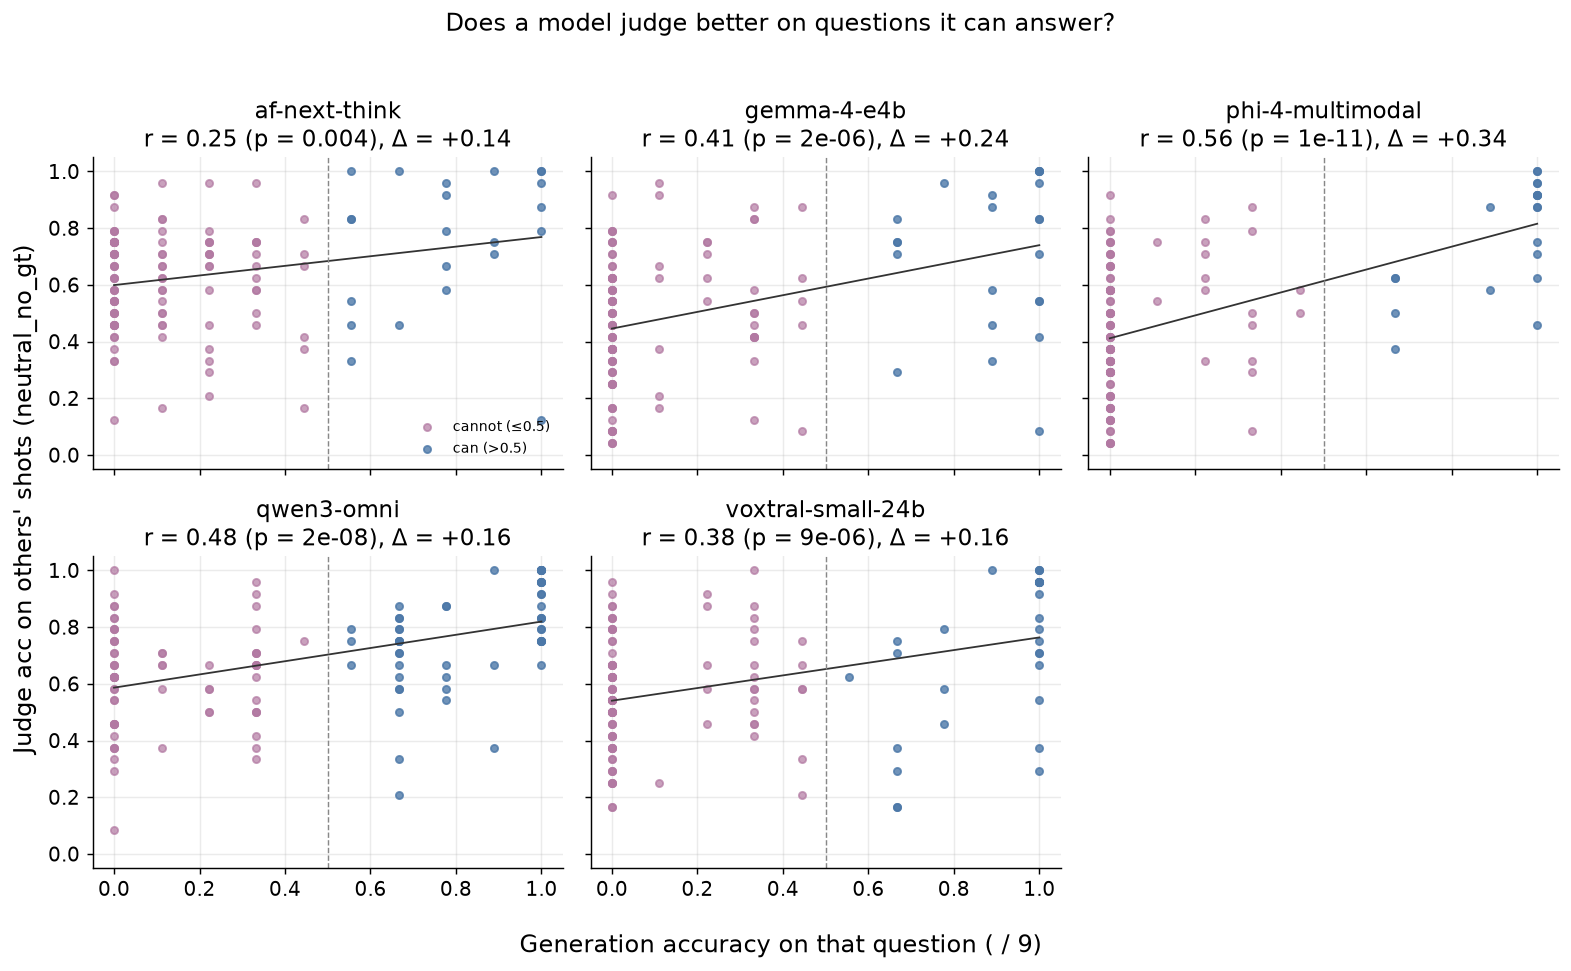

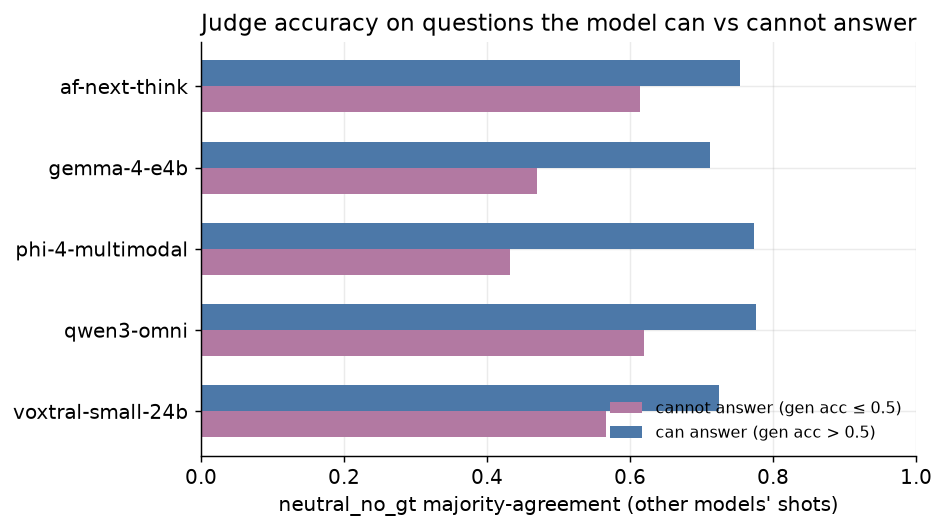

In [24]:
models = list(per_model_df["model"])
n_models = len(models)
ncols = min(3, n_models)
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.1 * ncols, 3.6 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
for ax, model in zip(axes, models):
    sub = q_df[q_df["model"] == model].dropna(subset=["gen_acc", "judge_acc_others"])
    x = sub["gen_acc"].to_numpy(dtype=float)
    y = sub["judge_acc_others"].to_numpy(dtype=float)
    can = sub["can_answer"].to_numpy(dtype=bool)
    ax.scatter(x[~can], y[~can], s=16, color="#B279A2", alpha=0.7, label="cannot (≤0.5)")
    ax.scatter(x[can], y[can], s=16, color="#4C78A8", alpha=0.8, label="can (>0.5)")
    if len(sub) >= 2:
        slope, intercept = np.polyfit(x, y, 1)
        xs = np.linspace(0, 1, 40)
        ax.plot(xs, slope * xs + intercept, color="#333333", linewidth=1)
    row = per_model_df.set_index("model").loc[model]
    ax.set_title(f"{model}\nr = {row['r']:.2f} (p = {row['p']:.1g}), Δ = {row['delta']:+.2f}")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.axvline(0.5, color="#888888", linewidth=0.8, linestyle="--")
for ax in axes[n_models:]:
    ax.set_visible(False)
axes[0].legend(loc="lower right", fontsize=8, frameon=False)
fig.supxlabel("Generation accuracy on that question ( / 9)")
fig.supylabel("Judge acc on others' shots (neutral_no_gt)")
fig.suptitle("Does a model judge better on questions it can answer?", y=1.02)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.4, 0.48 * n_models + 1.8))
y = np.arange(n_models)
can = per_model_df["judge_can"].to_numpy(dtype=float)
cant = per_model_df["judge_cant"].to_numpy(dtype=float)
h = 0.32
ax.barh(y + h / 2, cant, height=h, color="#B279A2", label="cannot answer (gen acc ≤ 0.5)")
ax.barh(y - h / 2, can, height=h, color="#4C78A8", label="can answer (gen acc > 0.5)")
ax.set_yticks(y)
ax.set_yticklabels(per_model_df["model"])
ax.set_xlabel("neutral_no_gt majority-agreement (other models' shots)")
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.legend(loc="lower right", fontsize=9, frameon=False)
ax.set_title("Judge accuracy on questions the model can vs cannot answer")
fig.tight_layout()
plt.show()
